### <h1 align="center" >Fig. 1f: Curve fitting with Sigmoid function</h1>
This script is used to fit a sigmoid fit function to the pole-to-pole elongation distance of the *C. elegans* spindle during mitosis.

The following sigmoid function is implemented in this script:
<h1>
\begin{equation*}
y = b + \big(\frac{L}{1 + e^\frac{-(x-x0)}{\tau}}\big)
\end{equation*}
</h1>
From the curve fit, the following parameters were extracted:
* Initial length (Initial pole-to-pole distance)
* Final length (Final pole-to-pole distance)
* Metaphase length (Pole-to-pole distance at anaphase onset)
* Elongation rate (Rate of pole-to-pole elongation)

**`Input file`:** *.CSV* file containing the data of the pole-to-pole distance over time for each experiment.

The table below shows the table structure of each .csv file. The headers of each table should show the time series measurement value from each observation which starts with prefix, **Exp**, and other statistical values from the observations.

|Exp00 | Exp01 | Exp02 | Exp03 | Exp04 | Exp05 | mean | std | n | SE | time |
| :-----: | :-----: | :-----: | :-----: | :-----: | :-----: | :-----: | :-----: | :-----:| :-----: | :-----: |
| `num` | `num` | `num` | `num` | `num` | `num` | `num` | `num` | `num`| `num` | `num` |
| `...` | `...` | `...` | `...` | `...` | `...` | `...` | `...` | `...`| `...` | `...` |

**`OUTPUT FILES`**

A **.PNG** file showing the fitted plots and a **.CSV** file containing the extracted parameters from the fitting.


In [1]:
# libraries
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [76]:
# input folder
folder = r'D:\data\Analysis Data\python_analysis\input'
fileTable = os.listdir(folder)

# output folder
save_files = r'D:\data\Analysis Data\python_analysis\output'

In [77]:
# read out the input files
file_list = {}
for file in fileTable:
    filepath = os.path.join(folder, file)
    filename = os.path.basename(filepath)

    file_container = [
        '32-cell_ABalpa_pole_to_pole.csv'
    ]

    if filename in file_container:
        try:
            df = pd.read_csv(filepath, index_col=None, encoding='utf-8')
        except:
            df = pd.read_csv(filepath, index_col=None, encoding='cp1252')

        key = filename.replace('.csv', '')
        file_list[key] = df

In [78]:
# check the loaded file
file_list['32-cell_ABalpa_pole_to_pole'].head(3)

,Exp19pp,Exp20pp,Exp28pp,Exp29pp,Exp32pp,Exp42pp,Exp45pp,mean,median,std,n,SE,time
0,NaN,8.1129,5.1276,6.3647,6.0807,6.4315,5.4985,6.269317,6.2227,0.945820,6,0.386129,-103.0
1,NaN,7.9498,5.0531,6.6948,5.6726,5.9063,5.7155,6.165350,5.8109,0.932198,6,0.380568,-92.7
2,NaN,7.1558,4.3831,6.1780,5.7176,6.1787,5.5758,5.864833,5.9478,0.833060,6,0.340095,-82.4


In [79]:
# extract the time, data, mean, standard deviation columns and create a new dataframe
file_of_interest = file_list['32-cell_ABalpa_pole_to_pole']
time_column = file_of_interest.loc[:, file_of_interest.columns.str.startswith('time')]
data_table = file_of_interest.loc[:, file_of_interest.columns.str.contains('Exp')]
mean_table = file_of_interest.loc[:, file_of_interest.columns.str.contains('mean')]
std_table = file_of_interest.loc[:, file_of_interest.columns.str.contains('std')]

df1 = pd.concat([time_column, data_table], axis=1)
df2 = pd.concat([time_column, mean_table], axis=1)
df3 = pd.concat([time_column, std_table], axis=1)
main_table = pd.concat([time_column, data_table, mean_table, std_table], axis=1)

In [80]:
# sns.set_style(style='white')
# plt.figure(figsize=(5,5))
# for col in main_table.columns:
#     if col.startswith('Exp'):
#         ax = sns.scatterplot(data=main_table, x='time', y=col, marker='H', s=50, color='grey', alpha=0.3)
#         sns.lineplot(data=main_table, x='time', y=main_table['mean'], ax=ax, color='red', alpha=1)

In [81]:
# check new df
main_table_dropna = main_table.dropna(thresh=3)
main_table_dropna.head(3)

,time,Exp19pp,Exp20pp,Exp28pp,Exp29pp,Exp32pp,Exp42pp,Exp45pp,mean,std
0,-103.0,NaN,8.1129,5.1276,6.3647,6.0807,6.4315,5.4985,6.269317,0.945820
1,-92.7,NaN,7.9498,5.0531,6.6948,5.6726,5.9063,5.7155,6.165350,0.932198
2,-82.4,NaN,7.1558,4.3831,6.1780,5.7176,6.1787,5.5758,5.864833,0.833060


### Sigmoid function
Fit a sigmoid function to the data to determine the initial length, final length and the elongation rate of the pole-to-pole elongation distance.

In [82]:
'''
x = independent variable [time or position]
L = the lower asymptote of the sigmoid curve. It determines the minimum  value that the curve approaches as 't' approaches negative infinity.
b = the upper asymptote of the sigmoid curve. It represents the maximum value that the curve approaches as 't' goes to positive infinity.
x0 = x-value of the sigmoid's midpoint (the inflection point)
k = rate of growth (controlling the steepness of the curve around the inflection point)
'''

def sigmoid(x, L ,x0, k, b):
    y = L / (1 + np.exp(-k*(x-x0))) + b
    return y
    
# define x-values and y-values
x = main_table_dropna['time']
y_mean = main_table_dropna['mean']

# compute the initial guess
initial_guess = [max(y_mean)-min(y_mean), 5, 0.05, min(y_mean)]

# summarize the parameter
popt, pcov = curve_fit(sigmoid, x, y_mean, initial_guess, maxfev=10000)

'''
Define a sequence of inputs between the smallest and largest known inputs and define the fit.
Let the maximum input assume the maximum values of x.
'''
x_fit = np.arange(x.min()-0.01, x.max()+0.01, 0.01)
y_fit = sigmoid(x_fit, *popt)
L = popt[0]
x0 = popt[1]
k = popt[2]
b = popt[3]

initial_length = L
final_length = b + L
elongation_rate = ((L*k)/4)*60

# create a new dictionary for each parameter and add to the DataFrame fit_Result
fit_Result = pd.DataFrame()
parameters = {'Initial pole_pole length (µm)': initial_length, 
              'Final pole_pole length (µm)': final_length, 
              'Elongation rate (µm/min)': elongation_rate
             }

parameters_df = pd.DataFrame.from_dict(parameters, orient='index', columns=['32-cell_ABalpa_fit_values'])
fit_Result = pd.concat([fit_Result, parameters_df], axis=1)

fit_Result.index.names = ['fit_parameter']
fit_Result.to_csv(os.path.join(save_files, '32-cell_ABalpa_Pole_to_pole_fit.csv'), encoding='cp1252') # save table as csv file

### Visualize the data with the fitted curve

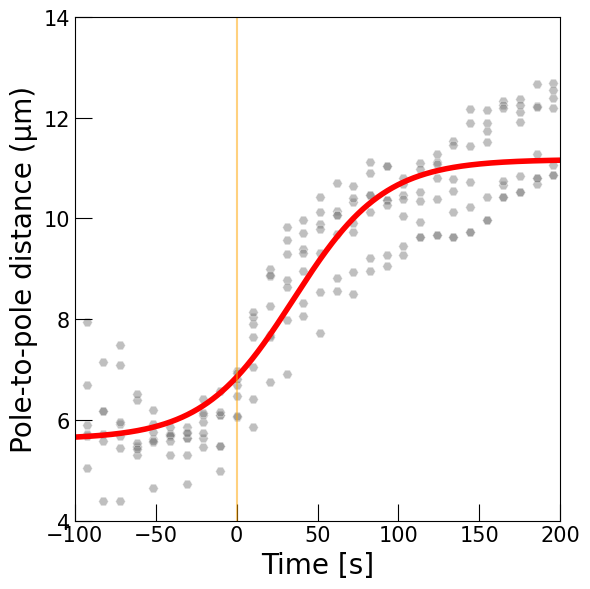

In [84]:
sns.set_style(style=None)
# plt.figure(figsize=(6,6))
fig, ax = plt.subplots(figsize=(6,6))

# iterate through the data columns
cells= [columnname for columnname in main_table_dropna if columnname.startswith('Exp')]

# plot the primary data
for i_columns in cells: 
    ax = sns.scatterplot(data=main_table_dropna, x=x, y=i_columns, color='grey', marker='H', alpha=0.5, s=50)

# plot the fit on the primary plot
sns.lineplot(x=x_fit, y=y_fit, alpha = 1, color='red', linewidth=4, ax=ax)

# add a vertical line at time 0 sec to indicate anaphase onset
ax.vlines(x=0, ymin=0, ymax=30, linestyle='solid', color='orange', alpha=0.5)

# add the desired features on the plot
ax.set_xlabel('Time [s]', fontsize= 20)
ax.set_ylabel('Pole-to-pole distance (μm)', fontsize= 20)
ax.tick_params(axis='both', which='major', labelsize=15, direction='in', length=12)
# plt.gca().tick_params(axis='both', which='major', labelsize=15)
# plt.gca().tick_params(axis='x', direction='in', length=15)
# plt.gca().tick_params(axis='y', direction='in', length=15)
ax.set(ylim=(4, 13.5+.5), xlim=(-100, 200))
plt.tight_layout()
ax.figure.savefig(os.path.join(save_files, '32-cell_ABalpa.png'), dpi=400, bbox_inches='tight') # save as a PNG file